In [1]:
#23.1
import folium
ueh = (10.762622, 106.660172)
m = folium.Map(location=ueh, zoom_start=14)
places = [
    ("UEH", (10.762622, 106.660172), "Trung tâm"),
    ("Dinh Độc Lập", (10.7770348, 106.695488), "Di tích lịch sử"),
    ("Bệnh viện Từ Dũ", (10.7701, 106.6878), "Bệnh viện"),
    ("Saigon Centre", (10.7725, 106.7000), "Trung tâm thương mại"),
    ("Bến xe Chợ Lớn", (10.7546, 106.6520), "Bến xe"),
    ("UBND TP.HCM", (10.7766, 106.7019), "Cơ quan hành chính")
]

for name, coord, desc in places:
    folium.Marker(location=coord, popup=f"{name} - {desc}").add_to(m)
folium.LayerControl().add_to(m)
m

In [2]:
#23.2
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
geolocator=Nominatim(user_agent="geoapi")
center_loc=geolocator.geocode("UEH, Ho Chi Minh City")
center=(center_loc.latitude,center_loc.longitude)
addresses=["Dinh Doc Lap, Ho Chi Minh City","Ben Thanh Market, Ho Chi Minh City","Saigon Notre-Dame Basilica, Ho Chi Minh City","Central Post Office, Ho Chi Minh City","Landmark 81, Ho Chi Minh City","Bitexco Financial Tower, Ho Chi Minh City","Ho Con Rua, Ho Chi Minh City","Saigon Opera House, Ho Chi Minh City","Nguyen Hue Walking Street, Ho Chi Minh City","Vinh Nghiem Pagoda, Ho Chi Minh City"]
m=folium.Map(location=center,zoom_start=13)
folium.Marker(center,popup="UEH - Điểm trung tâm",icon=folium.Icon(color="red")).add_to(m)
for addr in addresses:
    loc=geolocator.geocode(addr)
    if loc:
        point=(loc.latitude,loc.longitude)
        d=geodesic(center,point).km
        print(f"{addr}: {point} - {d:.2f} km")
        folium.Marker(point,popup=f"{addr}<br>Khoảng cách: {d:.2f} km").add_to(m)
        folium.PolyLine([center,point],color="blue").add_to(m)
m

Dinh Doc Lap, Ho Chi Minh City: (10.7770348, 106.695488) - 0.66 km


Ben Thanh Market, Ho Chi Minh City: (10.7725301, 106.6980365) - 1.21 km


Central Post Office, Ho Chi Minh City: (10.7682145, 106.693281) - 1.65 km
Landmark 81, Ho Chi Minh City: (10.7969577, 106.7504543) - 6.27 km
Bitexco Financial Tower, Ho Chi Minh City: (10.7718634, 106.7044633) - 1.62 km
Ho Con Rua, Ho Chi Minh City: (10.7826372, 106.6959464) - 0.12 km
Saigon Opera House, Ho Chi Minh City: (10.7767437, 106.7032488) - 1.15 km
Nguyen Hue Walking Street, Ho Chi Minh City: (10.7737196, 106.7040457) - 1.43 km
Vinh Nghiem Pagoda, Ho Chi Minh City: (10.7903966, 106.6823772) - 1.59 km


In [3]:
#23.3
import folium
from folium.plugins import HeatMap
m=folium.Map(location=[10.776,106.700],zoom_start=13)
heat_data=[[10.772,106.698],[10.773,106.699],[10.774,106.700],[10.775,106.701],[10.776,106.702],[10.777,106.703],[10.778,106.704],[10.774,106.700],[10.775,106.700],[10.776,106.700],[10.777,106.701],[10.778,106.702]]
HeatMap(heat_data).add_to(m)
m

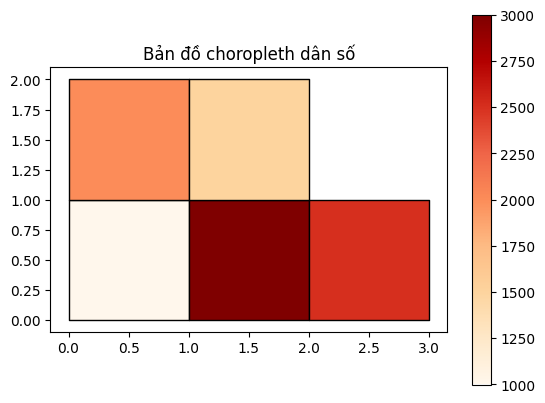

In [4]:
#23.4
import geopandas as gpd
from shapely.geometry import Polygon
import pandas as pd
import matplotlib.pyplot as plt
polygons=[Polygon([(0,0),(1,0),(1,1),(0,1)]),Polygon([(1,0),(2,0),(2,1),(1,1)]),Polygon([(0,1),(1,1),(1,2),(0,2)]),Polygon([(1,1),(2,1),(2,2),(1,2)]),Polygon([(2,0),(3,0),(3,1),(2,1)])]
gdf=gpd.GeoDataFrame({"khu_vuc":["A","B","C","D","E"]},geometry=polygons)
data=pd.DataFrame({"khu_vuc":["A","B","C","D","E"],"dan_so":[1000,3000,2000,1500,2500]})
merged=gdf.merge(data,on="khu_vuc")
merged.plot(column="dan_so",cmap="OrRd",legend=True,edgecolor="black")
plt.title("Bản đồ choropleth dân số")
plt.show()

In [5]:
#23.5
import folium
center=(10.762622,106.660172)
m=folium.Map(location=center,zoom_start=12)
folium.Marker(center,popup="Trung tâm phân phối").add_to(m)
for r,color in [(3000,"blue"),(5000,"green"),(10000,"red")]:
    folium.Circle(location=center,radius=r,color=color,fill=True,fill_opacity=0.1,popup=f"Bán kính {r/1000:.0f} km").add_to(m)
m

In [7]:
pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.5 MB/s eta 0:00:00


Số nút giao: 989
Số cạnh đường: 2090


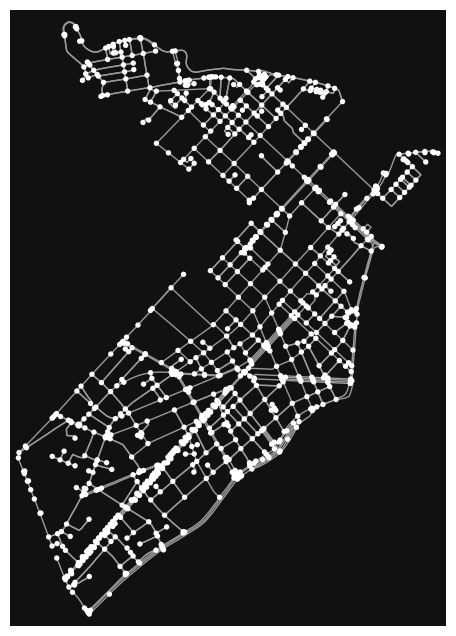

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [8]:
#23.6
import osmnx as ox
place="District 1, Ho Chi Minh City, Vietnam"
G=ox.graph_from_place(place,network_type="drive")
print("Số nút giao:",len(G.nodes))
print("Số cạnh đường:",len(G.edges))
ox.plot_graph(G)

In [17]:
#23.7
import osmnx as ox
import networkx as nx
import folium
place="District 1, Ho Chi Minh City, Vietnam"
G=ox.graph_from_place(place,network_type="drive")
start_point=(10.7770348,106.695488)
end_point=(10.7720,106.7030)
orig=ox.distance.nearest_nodes(G,X=start_point[1],Y=start_point[0])
dest=ox.distance.nearest_nodes(G,X=end_point[1],Y=end_point[0])
route_dijkstra=nx.shortest_path(G,orig,dest,weight="length")
route_astar=nx.astar_path(G,orig,dest,weight="length")
print("Số nút tuyến Dijkstra:",len(route_dijkstra))
print("Số nút tuyến A*:",len(route_astar))
m=folium.Map(location=start_point,zoom_start=14)
folium.Marker(start_point,popup="Điểm đầu").add_to(m)
folium.Marker(end_point,popup="Điểm cuối").add_to(m)
route_coords=[(G.nodes[n]["y"],G.nodes[n]["x"]) for n in route_dijkstra]
folium.PolyLine(route_coords,color="blue",weight=5,popup="Dijkstra").add_to(m)
m

Số nút tuyến Dijkstra: 15
Số nút tuyến A*: 15


In [9]:
#23.8
from geopy.distance import geodesic
import folium
drivers={"Xe 1":(10.776,106.700),"Xe 2":(10.770,106.690),"Xe 3":(10.765,106.680)}
customers={"Khách A":(10.772,106.705),"Khách B":(10.768,106.688),"Khách C":(10.764,106.679)}
m=folium.Map(location=[10.770,106.690],zoom_start=13)
for dname,dcoord in drivers.items(): folium.Marker(dcoord,popup=dname,icon=folium.Icon(color="blue")).add_to(m)
for cname,ccoord in customers.items():
    folium.Marker(ccoord,popup=cname,icon=folium.Icon(color="red")).add_to(m)
    nearest_driver=min(drivers.items(),key=lambda x: geodesic(x[1],ccoord).km)
    dname,dcoord=nearest_driver
    dist=geodesic(dcoord,ccoord).km
    print(f"{cname} được gán cho {dname}, khoảng cách {dist:.2f} km")
    folium.PolyLine([dcoord,ccoord],color="green").add_to(m)
m

Khách A được gán cho Xe 1, khoảng cách 0.70 km
Khách B được gán cho Xe 2, khoảng cách 0.31 km
Khách C được gán cho Xe 3, khoảng cách 0.16 km


In [10]:
#23.9
import pandas as pd
from sklearn.cluster import KMeans
import folium
points=[[10.772,106.700],[10.773,106.701],[10.774,106.702],[10.760,106.680],[10.761,106.681],[10.762,106.682],[10.780,106.710],[10.781,106.711],[10.782,106.712]]
df=pd.DataFrame(points,columns=["lat","lon"])
kmeans=KMeans(n_clusters=3,random_state=42)
df["cluster"]=kmeans.fit_predict(df[["lat","lon"]]).astype(int)
m=folium.Map(location=[10.772,106.700],zoom_start=13)
colors=["red","blue","green"]
for _,row in df.iterrows(): folium.CircleMarker(location=[row["lat"],row["lon"]],radius=6,color=colors[int(row["cluster"])],fill=True,fill_color=colors[int(row["cluster"])],fill_opacity=0.7,popup=f"Cụm {int(row['cluster'])}").add_to(m)
for center in kmeans.cluster_centers_: folium.Marker(center.tolist(),popup="Tâm cụm / điểm trung chuyển").add_to(m)
m

In [11]:
#23.10
import folium
m=folium.Map(location=[10.776,106.700],zoom_start=13)
traffic_points=[("Ngã tư A",(10.776,106.700),85),("Ngã tư B",(10.774,106.698),65),("Ngã tư C",(10.772,106.696),40),("Ngã tư D",(10.778,106.704),90),("Ngã tư E",(10.780,106.706),55)]
for name,coord,risk in traffic_points:
    if risk>=80: color="red"; level="Nguy cơ cao"
    elif risk>=60: color="orange"; level="Nguy cơ trung bình"
    else: color="green"; level="Nguy cơ thấp"
    folium.CircleMarker(location=coord,radius=8,color=color,fill=True,popup=f"{name} - {level} - Chỉ số: {risk}").add_to(m)
alt_route=[(10.771,106.694),(10.773,106.697),(10.775,106.699)]
folium.PolyLine(alt_route,color="blue",weight=5,popup="Tuyến thay thế").add_to(m)
m

In [12]:
#23.11
import pandas as pd
from sklearn.linear_model import LinearRegression
data=pd.DataFrame({"gio":[7,8,9,17,18,19,20],"mat_do_dan_so":[80,80,80,80,80,80,80],"nhu_cau":[120,150,130,180,220,200,160]})
X=data[["gio","mat_do_dan_so"]]
y=data["nhu_cau"]
model=LinearRegression()
model.fit(X,y)
test=pd.DataFrame({"gio":[10,12,18],"mat_do_dan_so":[80,80,80]})
pred=model.predict(test)
print(pred)

[145.51020408 155.6122449  185.91836735]


In [13]:
#23.12
from geopy.distance import geodesic
warehouses={"Kho 1":(10.762,106.660),"Kho 2":(10.780,106.700)}
orders={"Đơn A":(10.770,106.668),"Đơn B":(10.781,106.705),"Đơn C":(10.765,106.662),"Đơn D":(10.779,106.699)}
assignment={}
for oname,ocoord in orders.items():
    nearest_wh=min(warehouses.items(),key=lambda x: geodesic(x[1],ocoord).km)
    assignment[oname]=nearest_wh[0]
    print(f"{oname} -> {nearest_wh[0]}")

Đơn A -> Kho 1
Đơn B -> Kho 2
Đơn C -> Kho 1
Đơn D -> Kho 2


In [14]:
#23.13
import folium
m=folium.Map(location=[10.776,106.700],zoom_start=13)
fg_points=folium.FeatureGroup(name="Điểm")
fg_routes=folium.FeatureGroup(name="Tuyến đường")
fg_areas=folium.FeatureGroup(name="Vùng")
folium.Marker([10.777,106.695],popup="Dinh Độc Lập").add_to(fg_points)
folium.Marker([10.779,106.699],popup="Nhà thờ Đức Bà").add_to(fg_points)
folium.PolyLine([[10.777,106.695],[10.779,106.699]],color="blue").add_to(fg_routes)
folium.Circle([10.776,106.700],radius=2000,color="red",fill=True,fill_opacity=0.1).add_to(fg_areas)
fg_points.add_to(m)
fg_routes.add_to(m)
fg_areas.add_to(m)
folium.LayerControl().add_to(m)
m

In [15]:
#23.14
import time
car_positions=[(10.770,106.690),(10.771,106.691),(10.772,106.692),(10.773,106.693),(10.774,106.694)]
for step,pos in enumerate(car_positions,start=1):
    print(f"Bước {step}: xe ở vị trí {pos}")
    time.sleep(1)

Bước 1: xe ở vị trí (10.77, 106.69)
Bước 2: xe ở vị trí (10.771, 106.691)
Bước 3: xe ở vị trí (10.772, 106.692)
Bước 4: xe ở vị trí (10.773, 106.693)
Bước 5: xe ở vị trí (10.774, 106.694)


In [16]:
#23.15
import folium
from sklearn.cluster import KMeans
import pandas as pd
customers=pd.DataFrame({"lat":[10.772,10.773,10.774,10.780,10.781,10.782],"lon":[106.700,106.701,106.702,106.710,106.711,106.712]})
kmeans=KMeans(n_clusters=2,random_state=42)
customers["cluster"]=kmeans.fit_predict(customers[["lat","lon"]])
m=folium.Map(location=[10.776,106.705],zoom_start=13)
for _,row in customers.iterrows(): folium.CircleMarker([row["lat"],row["lon"]],radius=5,color="blue",fill=True).add_to(m)
for center in kmeans.cluster_centers_: folium.Marker(center.tolist(),popup="Vị trí cửa hàng đề xuất",icon=folium.Icon(color="red")).add_to(m)
m